In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from pathlib import Path

In [2]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

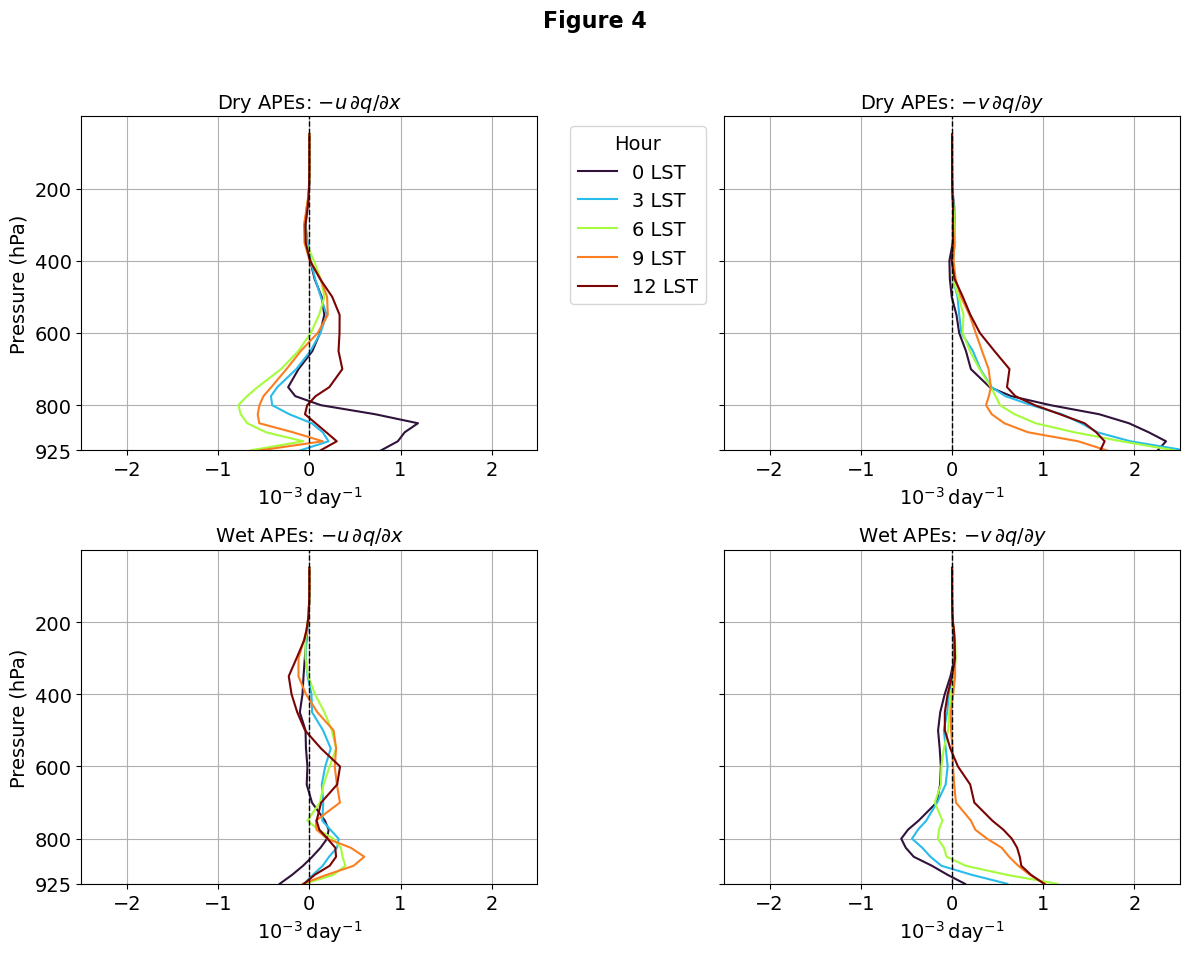

In [23]:
# these are the correct version -> using a single gridpoint to center the APE, and gradients with only adjacent points

folder = Path.home() / "advection_profiles_single_gridpoint_2001_2025"

# --- hours you want to plot ---

hours = [0, 3, 6, 9, 12]

# --- storage dictionaries ---

zonal_advection_data = {}

meridional_advection_data = {}

# --- load data for each hour ---
for hr in hours:
    
    fp = folder / f"{hr}lst_advection_profile.pkl"
    
    with open(fp, "rb") as f:
        
        data = pickle.load(f)

    # store
    
    zonal_advection_data[hr] = data['zonal'] 
    
    meridional_advection_data[hr] = data['meridional'] 

# --- assume pressure is identical for all files ---

pressure = np.array(pressure)

pressure_masked = pressure[pressure <= 925]

# --- Set up figure ---
colors = plt.cm.turbo(np.linspace(0, 1, len(hours)))

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

axs = axs.flatten()

titles = [
    
    r"Dry APEs: $-u \, \partial q / \partial x$",
    r"Dry APEs: $-v \, \partial q / \partial y$",
    r"Wet APEs: $-u \, \partial q / \partial x$",
    r"Wet APEs: $-v \, \partial q / \partial y$"
]

# plotting loop
for i, hr in enumerate(hours):
    
    color = colors[i]

    # extract profiles, mask to same pressure mask
    zon_dry = np.array(zonal_advection_data[hr]["dry"]*1000)[pressure <= 925]
    
    mer_dry = np.array(meridional_advection_data[hr]["dry"]*1000)[pressure <= 925]
    
    zon_wet = np.array(zonal_advection_data[hr]["wet"]*1000)[pressure <= 925]
    
    mer_wet = np.array(meridional_advection_data[hr]["wet"]*1000)[pressure <= 925]

    axs[0].plot(zon_dry, pressure_masked, color=color, label=f"{hr} LST")
    
    axs[1].plot(mer_dry, pressure_masked, color=color)
    
    axs[2].plot(zon_wet, pressure_masked, color=color)
    
    axs[3].plot(mer_wet, pressure_masked, color=color)

# Style subplots
for ax, title in zip(axs, titles):
    
    ax.set_title(title, fontsize=14)
    
    ax.set_xlim(-2.5, 2.5)
    
    ax.set_ylim(0, np.max(pressure_masked))
    
    yticks = [925, 800, 600, 400, 200]
    
    ax.set_yticks(yticks)
    
    ax.set_yticklabels([str(int(p)) for p in yticks], fontsize=14)
    
    ax.set_xlabel(r"$10^{-3} \, \mathrm{day}^{-1}$", fontsize=14)
    
    ax.grid(True)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    
    ax.tick_params(axis='x', labelsize=14)
    
    ax.tick_params(axis='y', labelsize=14)

# labels on left panels
axs[0].set_ylabel("Pressure (hPa)", fontsize=14)

axs[2].set_ylabel("Pressure (hPa)", fontsize=14)

axs[0].legend(title="Hour", fontsize=14, title_fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Figure 4", fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.gca().invert_yaxis()


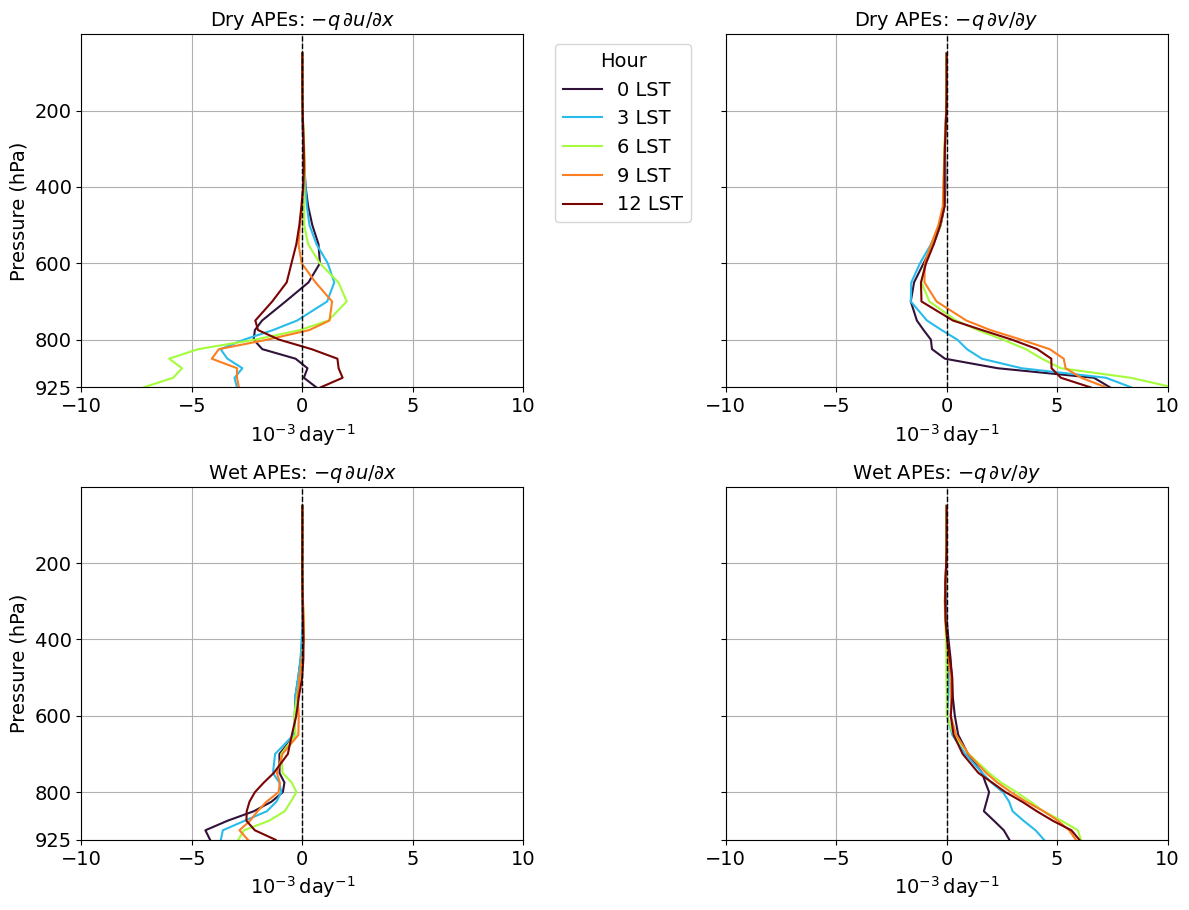

In [24]:
# these are the correct version -> using a single gridpoint to center the APE, and gradients with only adjacent points

folder = Path.home() / "convergence_profiles_single_gridpoint_2001_2025"

# --- hours you want to plot ---
hours = [0, 3, 6, 9, 12]

# --- storage dictionaries ---
zonal_convergence_data = {}

meridional_convergence_data = {}

# --- load data for each hour ---
for hr in hours:
    
    fp = folder / f"{hr}lst_convergence_profile.pkl"
    
    with open(fp, "rb") as f:
        
        data = pickle.load(f)

    # store
    
    zonal_convergence_data[hr] = data['zonal'] 
    
    meridional_convergence_data[hr] = data['meridional'] 

# --- assume pressure is identical for all files ---

pressure = np.array(pressure)

pressure_masked = pressure[pressure <= 925]

# --- Set up figure ---
colors = plt.cm.turbo(np.linspace(0, 1, len(hours)))

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

axs = axs.flatten()

titles = [
    r"Dry APEs: $-q \, \partial u / \partial x$",
    r"Dry APEs: $-q \, \partial v / \partial y$",
    r"Wet APEs: $-q \, \partial u / \partial x$",
    r"Wet APEs: $-q \, \partial v / \partial y$"
]

# plotting loop
for i, hr in enumerate(hours):
    
    color = colors[i]

    # extract profiles, mask to same pressure mask
    zon_dry = np.array(zonal_convergence_data[hr]["dry"]*1000)[pressure <= 925]
    
    mer_dry = np.array(meridional_convergence_data[hr]["dry"]*1000)[pressure <= 925]
    
    zon_wet = np.array(zonal_convergence_data[hr]["wet"]*1000)[pressure <= 925]
    
    mer_wet = np.array(meridional_convergence_data[hr]["wet"]*1000)[pressure <= 925]

    axs[0].plot(zon_dry, pressure_masked, color=color, label=f"{hr} LST")
    
    axs[1].plot(mer_dry, pressure_masked, color=color)
    
    axs[2].plot(zon_wet, pressure_masked, color=color)
    
    axs[3].plot(mer_wet, pressure_masked, color=color)

# Style subplots
for ax, title in zip(axs, titles):
    
    ax.set_title(title, fontsize=14)
    
    ax.set_xlim(-10, 10)
    
    ax.set_ylim(0, np.max(pressure_masked))
    
    yticks = [925, 800, 600, 400, 200]
    
    ax.set_yticks(yticks)
    
    ax.set_yticklabels([str(int(p)) for p in yticks], fontsize=14)
    
    ax.set_xlabel(r"$10^{-3} \, \mathrm{day}^{-1}$", fontsize=14)
    
    ax.grid(True)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    
    ax.tick_params(axis='x', labelsize=14)
    
    ax.tick_params(axis='y', labelsize=14)

# labels on left panels
axs[0].set_ylabel("Pressure (hPa)", fontsize=14)

axs[2].set_ylabel("Pressure (hPa)", fontsize=14)

axs[0].legend(title="Hour", fontsize=14, title_fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.gca().invert_yaxis()

In [5]:
with open('/home/annierosen16/master_2001_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [6]:
with open('/home/annierosen16/diurnal_time_tendency_2001_2025.pkl', 'rb') as f:
    
    data = pickle.load(f)

diurnal_time_tendency_dry = list(data['dry'])

diurnal_time_tendency_wet = list(data['wet'])

In [7]:
# Load the pickle file

with open('/home/annierosen16/diurnal_sfc_term_2001_2025.pkl', 'rb') as f:
    
    data = pickle.load(f)

diurnal_sfc_term_dry = data['dry'] * 1000

diurnal_sfc_term_wet = data['wet'] * 1000

#### evapotranspiration

In [8]:
with open('/home/annierosen16/et_composites_2001_2025.pkl', 'rb') as f:
    
    diurnal_et = pickle.load(f)
    
    diurnal_et_dry = diurnal_et['dry']
    
    diurnal_et_wet = diurnal_et['wet']

#### precipitation

In [9]:
dry_case = master[master['dryape']==True]

wet_case = master[master['wetape']==True]

hr_to_day = 24

# stack daily_precip arrays and compute the hourly average

diurnal_precip_dry = np.vstack(dry_case['daily_precip'].values).mean(axis=0) * hr_to_day

diurnal_precip_wet = np.vstack(wet_case['daily_precip'].values).mean(axis=0) * hr_to_day

#### apply domain mean surface pressure mask

In [10]:
def apply_pressure_mask(nested_dict):
    
    pressure_mask = pressure <= 925

    masked_dict = {}

    for outer_key, inner_dict in nested_dict.items():
        
        masked_dict[outer_key] = {}
        
        for inner_key, array in inner_dict.items():
            
            masked_dict[outer_key][inner_key] = array[pressure_mask]
    
    return masked_dict

zonal_advection_data = apply_pressure_mask(zonal_advection_data)

zonal_convergence_data = apply_pressure_mask(zonal_convergence_data)

meridional_advection_data = apply_pressure_mask(meridional_advection_data)

meridional_convergence_data = apply_pressure_mask(meridional_convergence_data)

#### horizontal convergence & advection

In [11]:
## vertically integrate horizontal convergence & advection

def vertically_integrated_profile_in_pressure(profile, levels):
    
    g = 9.81  # Gravitational acceleration in m/s^2
    
    rho_water = 1000  # Density of water in kg/m^3
    
    m_to_mm = 1000
                    
    dp = np.diff(levels)
            
    integrated_value = (np.sum(0.5 * (profile[:-1] + profile[1:]) * dp) / (g * rho_water)) * m_to_mm

    return integrated_value

def integrate_profiles(data, pressure, unit_adjustment=1000, apply_unit_adjustment=True):
    
    pressure_for_integration = pressure * 100 # conversion to Pa
        
    integrated_profiles = {}

    for time, label_dict in data.items():
        
        integrated_profiles[time] = {}
        
        for label, profile in label_dict.items():
            
            if apply_unit_adjustment:
                
                profile = profile / unit_adjustment
            
            integrated_profiles[time][label] = vertically_integrated_profile_in_pressure(profile, pressure_for_integration)
    
    return integrated_profiles

## units = mm/day

integrated_zonal_advection_profiles = integrate_profiles(zonal_advection_data, pressure_masked, apply_unit_adjustment=False)

integrated_meridional_advection_profiles = integrate_profiles(meridional_advection_data, pressure_masked, apply_unit_adjustment=False)

integrated_zonal_convergence_profiles = integrate_profiles(zonal_convergence_data, pressure_masked, apply_unit_adjustment=False)

integrated_meridional_convergence_profiles = integrate_profiles(meridional_convergence_data, pressure_masked, apply_unit_adjustment=False)

In [12]:
def extract_diurnal_cycles(data_dict):
    
    """
    
    data_dict: {hour: {'dry': scalar, 'wet': scalar}}
    
    Returns hours sorted, and dry/wet arrays in that order.
    
    """
    
    sorted_hours = sorted(data_dict.keys())
    
    dry_values = np.array([data_dict[hour]['dry'] for hour in sorted_hours])
    
    wet_values = np.array([data_dict[hour]['wet'] for hour in sorted_hours])
    
    return sorted_hours, dry_values, wet_values

hours_zonal_adv, diurnal_zonal_advection_dry, diurnal_zonal_advection_wet = extract_diurnal_cycles(integrated_zonal_advection_profiles)

hours_merid_adv, diurnal_meridional_advection_dry, diurnal_meridional_advection_wet = extract_diurnal_cycles(integrated_meridional_advection_profiles)

hours_zonal_conv, diurnal_zonal_convergence_dry, diurnal_zonal_convergence_wet = extract_diurnal_cycles(integrated_zonal_convergence_profiles)

hours_merid_conv, diurnal_meridional_convergence_dry, diurnal_meridional_convergence_wet = extract_diurnal_cycles(integrated_meridional_convergence_profiles)

#### creating self calculated MFC by summing all zonal, meridional, advection and convergence and surface components for both dry and wet APEs

In [13]:
self_calculated_mfc_dry = diurnal_zonal_advection_dry + diurnal_zonal_convergence_dry + diurnal_meridional_advection_dry + diurnal_meridional_convergence_dry + diurnal_sfc_term_dry

self_calculated_mfc_wet = diurnal_zonal_advection_wet + diurnal_zonal_convergence_wet + diurnal_meridional_advection_wet + diurnal_meridional_convergence_wet + diurnal_sfc_term_wet

In [14]:
with open('/home/annierosen16/self_calculated_mfc_2001_2025.pkl', 'wb') as f:
    
    pickle.dump(
        
        (self_calculated_mfc_dry, self_calculated_mfc_wet), f, protocol=pickle.HIGHEST_PROTOCOL)

#### master figure 

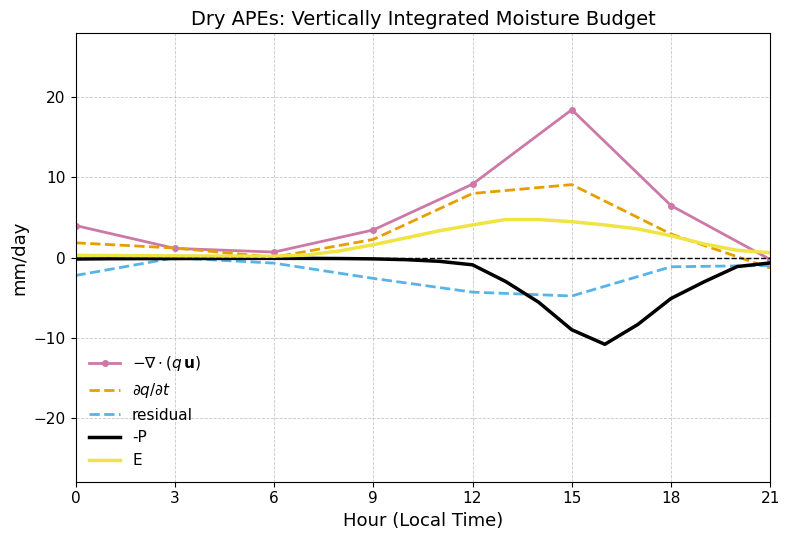

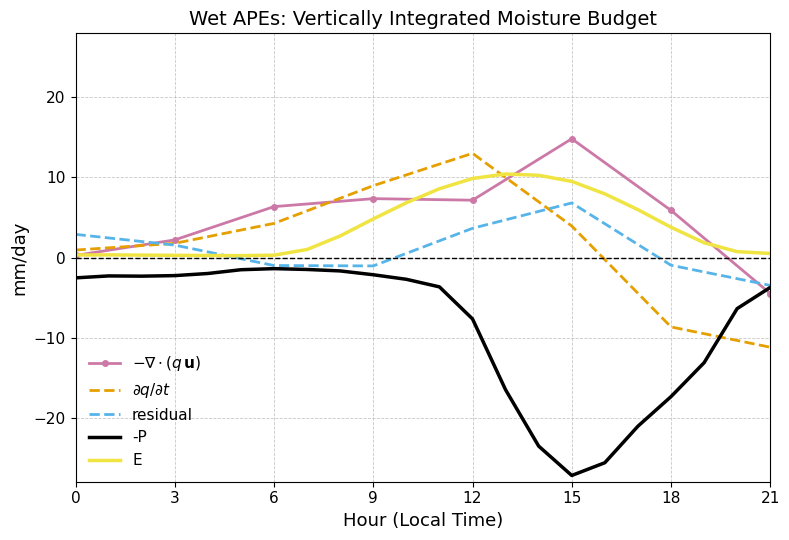

In [16]:
def plot_diurnal_moisture_budget(hours_24, precip, et, mer_adv, zon_adv, mer_conv, zon_conv, time_tend, sfc_term, title):
    
    precip = np.array(precip) * -1 # multiplication by -1 to be consistent with dq/dt = MFC - P + E form of budget
    
    et = np.array(et)
    
    mer_adv = np.array(mer_adv)
    
    zon_adv = np.array(zon_adv)
    
    mer_conv = np.array(mer_conv)
    
    zon_conv = np.array(zon_conv)
    
    time_tend = np.array(time_tend)
    
    sfc_term = np.array(sfc_term)

    # Only take every 3rd element for 3-hourly fields
    
    precip_3hr = precip[::3] * -1 # multiply by -1 to reverse back to positive values for residual calculation
    
    et_3hr = et[::3]
    
    hours_3hr = hours_24[::3]

    adv_total = zon_adv + mer_adv
    
    conv_total = zon_conv + mer_conv
    
    mfc_total = adv_total + conv_total + sfc_term
        
    residual = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term
        
    plt.figure(figsize=(8, 5.5))

    # Plot 3-hourly budget terms
    
#     plt.plot(hours_3hr, adv_total, label=r'$-\mathbf{u} \cdot \nabla q$', 
#          color='#D55E00', linewidth=2)          # Vermillion

    plt.plot(hours_3hr, mfc_total, label=r'$-\nabla \cdot (q \, \mathbf{u})$', 
         color='#CC79A7', linewidth=2, marker='o', markersize=4)  # Reddish purple

#     plt.plot(hours_3hr, conv_total, label=r'$-q \, \nabla \cdot \mathbf{u}$', 
#          color='#0072B2', linewidth=2)          # Blue

    plt.plot(hours_3hr, time_tend, label=r'$\partial q/\partial t$', 
         color='#E69F00', linestyle='--', linewidth=2)  # Orange

#     plt.plot(hours_3hr, sfc_term, label='sfc', 
#          color='#009E73', linestyle='--', linewidth=2)  # Bluish green

    plt.plot(hours_3hr, residual, label='residual', 
         color='#56B4E9', linestyle='--', linewidth=2)  # Sky blue

    plt.plot(hours_24, precip, label='-P', 
         color='#000000', linewidth=2.5)        # Black

    plt.plot(hours_24, et, label='E', 
         color='#F0E442', linewidth=2.5)        # Yellow

    # Axes and labels
    plt.xlabel('Hour (Local Time)', fontsize=13)
    
    plt.ylabel('mm/day', fontsize=13)
    
    plt.title(title, fontsize=14)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    
    plt.xticks(range(0, 24, 3), fontsize=11)
    
    plt.yticks(fontsize=11)
    
    plt.xlim(0, 21)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.legend(loc='lower left', fontsize=11, frameon=False)
    
    plt.tight_layout()
    
    plt.ylim(-28, 28)
    
    plt.show()

hours_24 = range(0,24)

# Plot for DRY APEs
plot_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_dry,
    
    diurnal_et_dry,
    
    diurnal_meridional_advection_dry,
    
    diurnal_zonal_advection_dry,
    
    diurnal_meridional_convergence_dry,
    
    diurnal_zonal_convergence_dry,
    
    diurnal_time_tendency_dry,
    
    diurnal_sfc_term_dry, 
    
    title='Dry APEs: Vertically Integrated Moisture Budget'
)

# Plot for WET APEs

plot_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_wet,
    
    diurnal_et_wet,
    
    diurnal_meridional_advection_wet,
    
    diurnal_zonal_advection_wet,
    
    diurnal_meridional_convergence_wet,
    
    diurnal_zonal_convergence_wet,
    
    diurnal_time_tendency_wet,
    
    diurnal_sfc_term_wet,
    
    title='Wet APEs: Vertically Integrated Moisture Budget')
